In [139]:
import graph_tool.collection 
import graph_tool.search 
import graph_tool as gt
import random
import numpy as np
import zstandard
import networkx as nx
import copy
import osmnx as ox

import random
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import subprocess
import ast
import datetime
import time

In [140]:
%load_ext autoreload
%autoreload 2

from src import utils as ut


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [141]:
place = 'Kyoto, Japan'
g = ut.get_nx_from_ox(place)
wgt = 'length'

G = ox.graph_from_place(place, network_type='drive')

In [142]:
st_pairs = 30 #number of source, target pairs

In [152]:
seed = 1919
st = ut.sample_st(g,st_pairs, seed = seed)

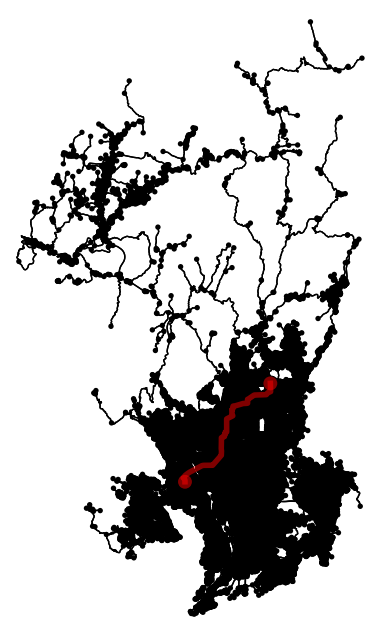

In [153]:
orig_node,dest_node = st[0][0],st[1][0]
route = nx.shortest_path(g, orig_node, dest_node, weight='length',method='dijkstra')
fig, ax = ox.plot_graph_route(G, route, bgcolor='white', edge_color='black', node_color='black')

In [145]:
fig, ax = ox.plot_graph_routes(G, ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
, bgcolor='white', edge_color='black', node_color='black')

KeyError: 1309884335

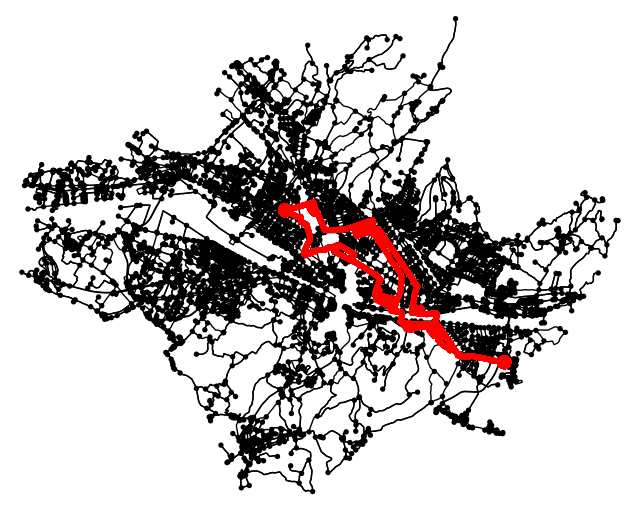

In [134]:
fig, ax = ox.plot_graph_routes(G, ut.sample_k_FP(dag, orig_node, dest_node,  100), bgcolor='white', edge_color='black', node_color='black')

In [154]:
folder_path = "/Users/antonioferrara/Desktop/GitHub/Maxmin-Fair-Paths/kspwlo-master/"
os.chdir(folder_path)
node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node,weight = wgt)
EKSP_node_map = ut.save_graph_to_gr_EKSP(g, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


In [155]:
dag = ut.get_dag(g, orig_node, dest_node, weight=wgt)
K, alpha, model, result = ut.iterative_solver(dag, orig_node, dest_node) #LP solver, alpha are the satisf. probs
final = ut.compute_probabilities_and_expectations(dag, result, dest_node) 
dag = final['dag']
nx.set_node_attributes(dag, alpha, 'node_flow')

In [156]:
%%time

init_time = time.time()
yen_k_shortest_10 = ut.yen_k_paths(g, orig_node, dest_node, weight=wgt, k=10)
ut.add_nodes_satisfaction(yen_k_shortest_10, dag, 'yen')
print(time.time()-init_time)

random_FP_paths = ut.sample_k_random_FP(dag, orig_node, dest_node,  100)
ut.add_nodes_satisfaction(random_FP_paths, dag, 'Random FP')
print(time.time()-init_time)


temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'OP+ 0.8 10')
print(time.time()-init_time)

temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 10')
print(time.time()-init_time)

  
with open('tmpQ.txt', 'w') as file:
    file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")
    
temp = EKSP_paths_05_10 = ut.inverse_mapping(ut.execute_EKSP("tmp_EKSP.gr", 10, 0.9), node_map)#it is with node_map results shifted by 1
ut.add_nodes_satisfaction(temp, dag, 'DKSP')
   

'''
temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 10')
print(time.time()-init_time)

temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.5 100')
print(time.time()-init_time)

temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 100')
print(time.time()-init_time)

#temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
#ut.add_nodes_satisfaction(temp, dag, 'OP+ 0.5 10')
'''


100.82916378974915
100.86582684516907
101.38916087150574
101.53538990020752
CPU times: user 1min 39s, sys: 509 ms, total: 1min 39s
Wall time: 1min 42s


'\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.8 10\')\nprint(time.time()-init_time)\n\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.5 100\')\nprint(time.time()-init_time)\n\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.8 100\')\nprint(time.time()-init_time)\n\n#temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "opplus"), node_map)\n#ut.add_nodes_satisfaction(temp, dag, \'OP+ 0.5 10\')\n'

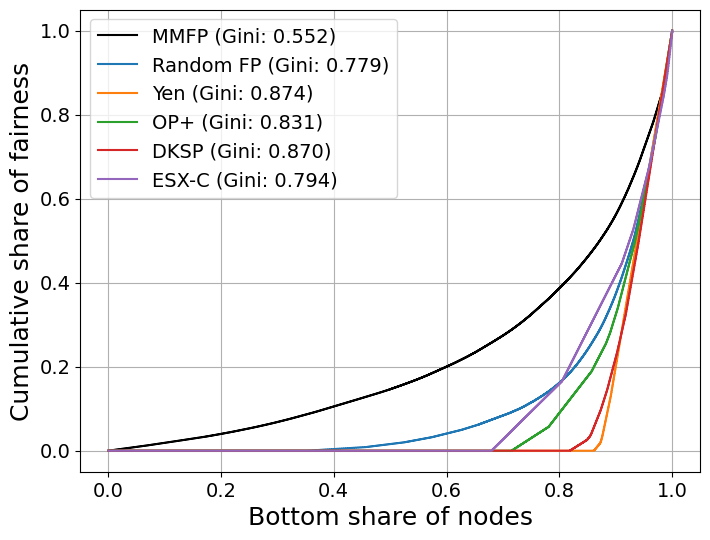

In [157]:
def plot_lorenz_curve(G, attributes=['node_flow'], legend_labels=None):
    """
    Compute and plot the Lorenz curve for the given attributes on the nodes of graph G.
    
    Parameters:
    G (networkx.DiGraph): Directed graph with node attributes.
    attributes (list): List of node attributes to compute the Lorenz curve for. Default is ['node_flow'].
    legend_labels (list or None): List of legend labels corresponding to each attribute. If None, labels are generated automatically.
    
    Returns:
    None: The function plots the Lorenz curves.
    """
    plt.figure(figsize=(8, 6))
    
    if legend_labels is None:
        legend_labels = [f'Lorenz Curve for {attr}' for attr in attributes]
    elif len(legend_labels) != len(attributes):
        raise ValueError("Number of legend labels must match the number of attributes.")
    
    # Create a new graph with nodes that have at least one non-zero attribute
    filtered_nodes = [
        (node, data) for node, data in dag.nodes(data=True)
        if any(data.get(attr, 0) != 0 for attr in attributes)
    ]
    filtered_graph = nx.DiGraph()
    filtered_graph.add_nodes_from(filtered_nodes)
    
    for attribute, label in zip(attributes, legend_labels):
        # Extract the flow values from the nodes in the filtered graph
        flow_values = np.array([data[attribute] for node, data in filtered_graph.nodes(data=True)])
        
        if len(flow_values) == 0:
            raise ValueError(f"No non-zero values found for attribute '{attribute}'")
        
        # Step 1: Sort the flow values in ascending order
        sorted_flow_values = np.sort(flow_values)
        
        # Step 2: Compute the cumulative sum of the sorted flow values
        cumulative_sum = np.cumsum(sorted_flow_values)
        
        # Step 3: Normalize the cumulative sum
        total_sum = cumulative_sum[-1]
        lorenz_curve = cumulative_sum / total_sum
        
        # Compute the Gini index
        gini_index = ut.compute_gini_index(lorenz_curve)
        
        # Add Gini index to the label
        #label_with_gini = f'{label} (Gini: {gini_index:.3f})'

        label_with_gini = f'{label} (Gini: {gini_index:.3f})'
        
        # Plot the Lorenz curve
        n = len(lorenz_curve)
        if label == 'MMFP':
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label_with_gini, color = 'black')
        else:
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label_with_gini)
    
    #plt.plot([0, 1], [0, 1], color='k', linestyle='--', label='Equality Line')
    
    plt.xlabel('Bottom share of nodes', fontsize=18)  # Larger x-axis label font size
    plt.ylabel('Cumulative share of fairness', fontsize=18)  # Larger y-axis label font size
    plt.legend(fontsize=14)  # Larger legend font size
    plt.grid(True)
    
    # Adjust xticks and yticks font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    
    current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    directory = '../FairShortPath/plots_lorenz'
    filename = f'{directory}/{place}_{str(seed)}methods.pdf'
    #plt.savefig(filename, bbox_inches='tight')
    plt.show()

    
    

attributes =  ['node_flow', 'Random FP', 'yen', 'OP+ 0.8 10','DKSP','ESX-C 0.8 10']
legend_labels =  ['MMFP',   'Random FP', 'Yen', 'OP+' ,      'DKSP', 'ESX-C' ]
plot_lorenz_curve(dag, attributes=attributes, legend_labels=legend_labels)

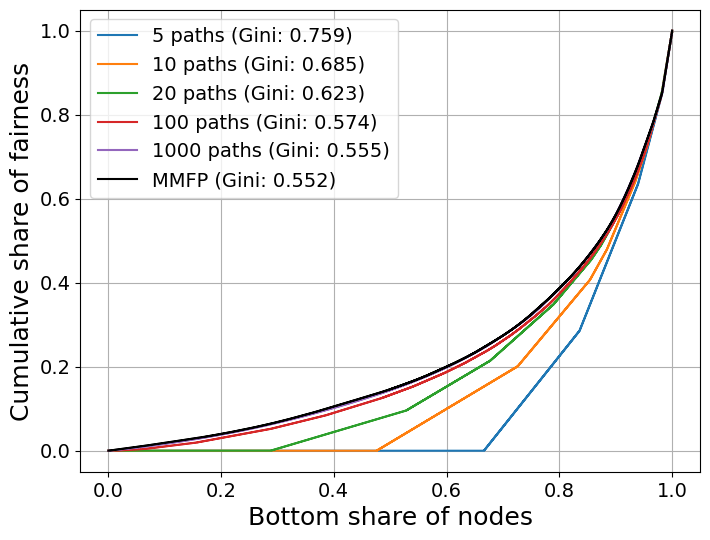

In [158]:
ks = [5, 10, 20, 100, 1000]


for k in ks:
    paths = ut.sample_k_FP(dag, orig_node, dest_node,  k)
    ut.add_nodes_satisfaction(paths, dag, str(k))

    
def plot_lorenz_curve(G, attributes=['node_flow'], legend_labels=None):
    """
    Compute and plot the Lorenz curve for the given attributes on the nodes of graph G.
    
    Parameters:
    G (networkx.DiGraph): Directed graph with node attributes.
    attributes (list): List of node attributes to compute the Lorenz curve for. Default is ['node_flow'].
    legend_labels (list or None): List of legend labels corresponding to each attribute. If None, labels are generated automatically.
    
    Returns:
    None: The function plots the Lorenz curves.
    """
    plt.figure(figsize=(8, 6))
    
    if legend_labels is None:
        legend_labels = [f'Lorenz Curve for {attr}' for attr in attributes]
    elif len(legend_labels) != len(attributes):
        raise ValueError("Number of legend labels must match the number of attributes.")
    
    # Create a new graph with nodes that have at least one non-zero attribute
    filtered_nodes = [
        (node, data) for node, data in dag.nodes(data=True)
        if any(data.get(attr, 0) != 0 for attr in attributes)
    ]
    filtered_graph = nx.DiGraph()
    filtered_graph.add_nodes_from(filtered_nodes)
    
    for attribute, label in zip(attributes, legend_labels):
        # Extract the flow values from the nodes in the filtered graph
        flow_values = np.array([data[attribute] for node, data in filtered_graph.nodes(data=True)])
        
        if len(flow_values) == 0:
            raise ValueError(f"No non-zero values found for attribute '{attribute}'")
        
        # Step 1: Sort the flow values in ascending order
        sorted_flow_values = np.sort(flow_values)
        
        # Step 2: Compute the cumulative sum of the sorted flow values
        cumulative_sum = np.cumsum(sorted_flow_values)
        
        # Step 3: Normalize the cumulative sum
        total_sum = cumulative_sum[-1]
        lorenz_curve = cumulative_sum / total_sum
        
        # Compute the Gini index
        gini_index = ut.compute_gini_index(lorenz_curve)
        
        # Add Gini index to the label
        #label_with_gini = f'{label} (Gini: {gini_index:.3f})'
        if label != 'MMFP':
            label_with_gini = f'{label} paths (Gini: {gini_index:.3f})'
        else:
            label_with_gini = f'{label} (Gini: {gini_index:.3f})'
        
        # Plot the Lorenz curve
        n = len(lorenz_curve)
        if label == 'MMFP':
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label_with_gini, color = 'black')
        else:
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label_with_gini)

    
    # Plot the equality line
    #plt.plot([0, 1], [0, 1], color='k', linestyle='--', label='Equality Line')
    
    plt.xlabel('Bottom share of nodes', fontsize=18)  # Larger x-axis label font size
    plt.ylabel('Cumulative share of fairness', fontsize=18)  # Larger y-axis label font size
    plt.legend(fontsize=14)  # Larger legend font size
    plt.grid(True)
    
    # Adjust xticks and yticks font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    directory = '../FairShortPath/plots_lorenz'
    filename = f'{directory}/{place}_{str(seed)}convergence.pdf'
    plt.savefig(filename, bbox_inches='tight')
    
    plt.show()

    
    
kstring = [str(k) for k in ks]  
attributes =   kstring + ['node_flow']
legend_labels =   kstring + ['MMFP']
plot_lorenz_curve(dag, attributes=attributes, legend_labels=legend_labels)